In [2]:
from train import *
from geo_rnns.neutraj_trainer import *

In [3]:
trajrnn = NeuTrajTrainer(tagset_size = config.d, batch_size = config.batch_size,
                            sampling_num = config.sampling_num)
trajrnn.data_prepare(griddatapath = config.gridxypath, coordatapath = config.corrdatapath,
                        distancepath = config.distancepath, train_radio = config.seeds_radio)
# load_model_name = None
# trajrnn.neutraj_train(load_model = config.load_model, in_cell_update=config.incell,
#                         stard_LSTM=config.stard_unit)

Training size:200
Padded Trajs shape
1096
max value in distance matrix :5.781731182309418
dtw
Distance shape
(200, 1005)
[0.         0.17780621 0.62481472 ... 0.14009925 0.23465874 0.15265666]
Train Distance shape
(200, 200)


In [4]:
# data_prepare
dataset_length = config.datalength

traj_grids, useful_grids, max_len = cPickle.load(open(config.gridxypath, 'rb'))
print(np.array(traj_grids).shape)

traj_coor, useful_grids, max_len = cPickle.load(open(config.corrdatapath, 'rb'))
print(np.array(traj_coor).shape, traj_coor[0])

distance = cPickle.load(open(config.distancepath, 'rb')) 
print(np.array(distance).shape, distance[0])

grid_trajs = [[[ii + config.spatial_width for ii in i] for i in tg]
                      for tg in traj_grids[:dataset_length]]

coor_trajs = traj_coor[:dataset_length]
train_size = int(len(grid_trajs) * config.seeds_radio /
                    trajrnn.batch_size) * trajrnn.batch_size

print("Training size:{}".format(train_size))

grid_train_seqs, grid_test_seqs = grid_trajs[:train_size], grid_trajs[train_size:]
coor_train_seqs, coor_test_seqs = coor_trajs[:train_size], coor_trajs[train_size:]

(1096, 24, 1)
(1096, 24, 1) [[0.2959003293032332], [0.2127660715510892], [0.17951235649359942], [0.14071637317647728], [0.16288551654813715], [0.17951235649359942], [0.2293929114965515], [0.4289151397725025], [0.5840990876351156], [0.6118105115747056], [0.6450642090489127], [0.5896413717197022], [0.5286762485475769], [0.4233728558637486], [0.30698489571407833], [0.37349230121246224], [0.3845768693816356], [0.5286762485475769], [0.6616910665776577], [0.67831790652312], [0.6062682257317907], [0.5231339644629901], [0.4510842748800195], [0.37349230121246224]]
(1000, 1005) [0.         1.0280277  3.61251078 ... 0.81001623 1.35673376 0.88261979]
Training size:200


In [5]:
pad_trjs = []
for i, t in enumerate(grid_trajs):
    traj = []
    for j, px in enumerate(t):
        coor_grid = coor_trajs[i][j] + px
        traj.append(coor_grid)
    pad_trjs.append(traj)

print(np.array(pad_trjs).shape, pad_trjs[0][:4], grid_trajs[0][:4])
print(trajrnn.padded_trajs[0][:4])

(1096, 24, 2) [[0.2959003293032332, 297], [0.2127660715510892, 214], [0.17951235649359942, 181], [0.14071637317647728, 142]] [[297], [214], [181], [142]]
[[2.95900329e-01 2.97000000e+02]
 [2.12766072e-01 2.14000000e+02]
 [1.79512356e-01 1.81000000e+02]
 [1.40716373e-01 1.42000000e+02]]


[[0.         0.17780621 0.62481472 ... 0.14009925 0.23465874 0.15265666]
 [0.17780621 0.         0.69715598 ... 0.15675212 0.17184455 0.11036385]
 [0.62481472 0.69715598 0.         ... 0.67024167 0.73841457 0.70860508]
 ...
 [0.21243    0.31236333 0.38700844 ... 0.23678565 0.31549683 0.27528764]
 [0.22352721 0.14479044 0.65570189 ... 0.20303411 0.10007105 0.13797484]
 [0.21833965 0.09960496 0.73646203 ... 0.20663921 0.12606772 0.13205422]]


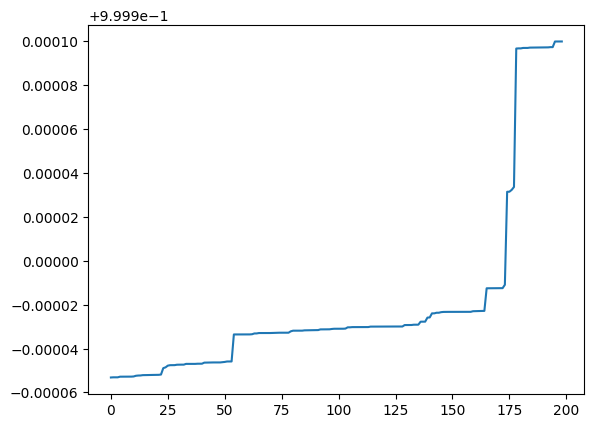

In [6]:
import matplotlib.pyplot as plt

# distance matrix
print(trajrnn.distance)

# distance sampling:
index = 0
train_seq_len = len(trajrnn.train_distance)
index_dis = distance[index]
pre_sort = [np.exp(-i*config.mail_pre_degree) for i in index_dis[:train_seq_len]]
sample_index = []
t = 0
importance = []
for i in pre_sort/np.sum(pre_sort):
    importance.append(t)
    t+=i
importance = np.array(importance)

plt.plot(importance[1:])

In [7]:
trajrnn.train_seqs[4]

[[0.24977537708140787, 251],
 [0.17633396716378236, 178],
 [0.15062947624218945, 152],
 [0.1359411932036674, 137],
 [0.1359411932036674, 137],
 [0.1653177592807115, 167],
 [0.24610330720094148, 248],
 [0.42970681318089277, 431],
 [0.532524775460602, 534],
 [0.6022941049477915, 604],
 [0.5619013362626613, 563],
 [0.5655734061431277, 567],
 [0.5361968453410683, 538],
 [0.4884599333783488, 490],
 [0.47744372373694965, 479],
 [0.506820284539009, 508],
 [0.5288527055801355, 530],
 [0.6500310116355262, 652],
 [0.6390148037524553, 641],
 [0.6096382552586938, 611],
 [0.5178364941804081, 519],
 [0.4958040731392816, 497],
 [0.38931404308909995, 391],
 [0.3085285004438547, 310]]

In [9]:
loader = trajrnn.batch_generator(trajrnn.train_seqs, trajrnn.train_distance)

In [15]:
batch = next(iter(loader))
inputs_arrays, inputs_len_arrays, target_arrays = batch[0], batch[1], batch[2]
anchor_input = torch.Tensor(inputs_arrays[0])
trajs_input = torch.Tensor(inputs_arrays[1])
negative_input = torch.Tensor(inputs_arrays[2])

anchor_input.shape, trajs_input.shape, negative_input.shape

(torch.Size([220, 24, 2]), torch.Size([220, 24, 2]), torch.Size([220, 24, 2]))

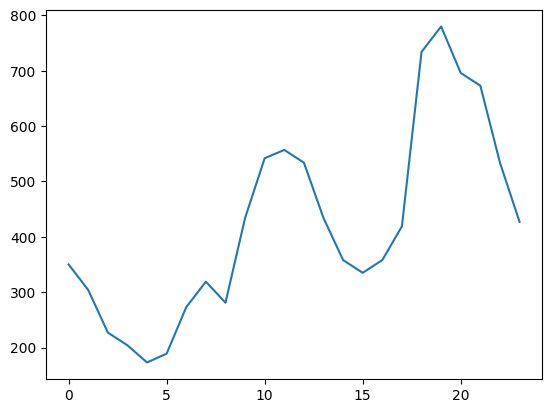

In [32]:
plt.plot(anchor_input[0][:,1].numpy())

In [21]:
printstats = lambda seq: print(seq.mean(), seq.std())
printstats(target_arrays[0])
printstats(target_arrays[1])

0.21828647390575645 0.2683698690557049
0.14785056593379492 0.28212877078145965


In [ ]:


spatial_net = NeuSeq_Network(2 * config.dimensional, trajrnn.target_size, trajrnn.grid_size, trajrnn.batch_size,
                                trajrnn.sampling_num,
                                stard_LSTM=config.stard_unit, incell=config.incell)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, spatial_net.parameters()),
                                lr=config.learning_rate)

mse_loss_m = WeightedRankingLoss(
    batch_size=trajrnn.batch_size, sampling_num=trajrnn.sampling_num)

AttributeError: 'NeuTrajTrainer' object has no attribute 'grid_size'

# sampling Q C for training NeuTS

In [2]:
import h5py
import os
import numpy as np

data_root = "../../final_data/"
dataset = "audio"
dataset_folder = os.path.join(data_root, dataset)
train_filepath = os.path.join(dataset_folder, "dataset_train.hdf5")

np.random.seed(69)
data = h5py.File(train_filepath, "r")
qlocs = np.random.choice(range(len(data['Q'])), size=4000, replace=False)
queries = data['Q'][:][qlocs]
clocs = np.random.choice(range(len(data['C'])), size=4000, replace=False)
corpuses = data['C'][:][clocs]

In [3]:
import torch

queries_flat = torch.from_numpy(queries)#.flatten(start_dim=1)
corpuses_flat = torch.from_numpy(corpuses)#.flatten(start_dim=1)

torch.save(queries_flat, "../naivedl/data/queries.pt")
torch.save(corpuses_flat, "../naivedl/data/corpuses.pt")

# RNNEncoder

In [26]:
from torch.nn import Module

import torch

class RNNEncoder(Module):
    def __init__(self, input_size, hidden_size):
        super(RNNEncoder, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.stard_LSTM = True
        self.dimensional = 1
        self.recurrent_unit = 'GRU'

        if self.stard_LSTM:
            if self.recurrent_unit=='GRU':
                self.cell = torch.nn.GRUCell(input_size - self.dimensional, hidden_size).cuda()
            elif self.recurrent_unit=='SimpleRNN':
                self.cell = torch.nn.RNNCell(input_size - self.dimensional, hidden_size).cuda()
            else:
                self.cell = torch.nn.LSTMCell(input_size - self.dimensional, hidden_size).cuda()

    def forward(self, inputs_a, initial_state = None):
        inputs, inputs_len = inputs_a
        time_steps = inputs.size(1)
        out = None
        if self.recurrent_unit == 'GRU' or self.recurrent_unit == 'SimpleRNN':
            out = initial_state
        else:
            out, state = initial_state
        outputs = []
        for t in range(time_steps):
            if self.stard_LSTM:
                cell_input = inputs[:, t, :][:,:-self.dimensional]
            else:
                cell_input = inputs[:, t, :]
            if self.recurrent_unit == 'GRU' or self.recurrent_unit == 'SimpleRNN':
                out = self.cell(cell_input, out)
            else:
                out, state = self.cell(cell_input, (out, state))
            outputs.append(out)
        mask_out = []
        for b, v in enumerate(inputs_len):
            mask_out.append(outputs[v-1][b,:].view(1,-1))
        return torch.cat(mask_out, dim = 0)

In [30]:
inputs = torch.randn(7, 6, 4000).cuda()
model = RNNEncoder(4000, 128)

In [33]:
model((inputs, [6]*7)).shape

torch.Size([7, 128])